In [2]:
import numpy as np
import os

DATA_PATH = r"C:\data\ntu_numpy"

print("Loading NTU60 subset...")
X = np.load(os.path.join(DATA_PATH, "X_ntu60.npy"))
y = np.load(os.path.join(DATA_PATH, "y_ntu60.npy"))

print("Before:", X.shape, y.shape)

# ---------- SAFETY NORMALIZATION ----------
# (idempotent — won't break if already normalized)
X = X.astype(np.float32)

mean = X.mean(axis=(1,2), keepdims=True)
std  = X.std(axis=(1,2), keepdims=True) + 1e-6

X = (X - mean) / std

# ---------- SHAPE CHECK ----------
if len(X.shape) == 4:
    N, T, J, C = X.shape
    X = X.reshape(N, T, J*C)

print("After reshape:", X.shape)

# ---------- FINAL CHECK ----------
print("NaNs:", np.isnan(X).any())
print("Label range:", y.min(), y.max())

# ---------- SAVE FINAL ----------
np.save(os.path.join(DATA_PATH, "X_train.npy"), X)
np.save(os.path.join(DATA_PATH, "y_train.npy"), y)

print("\n✅ FINAL DATA READY")

Loading NTU60 subset...
Before: (56880, 50, 75) (56880,)
After reshape: (56880, 50, 75)
NaNs: False
Label range: 0 59

✅ FINAL DATA READY


In [ ]:
# ========= HARD RESET =========
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

# ========= IMPORTS =========
import os
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ========= CONFIG =========
DATA_PATH = r"C:\data\ntu_numpy"

BATCH_SIZE = 256
EPOCHS = 35
LR = 1e-3

# ========= LOAD =========
print("Loading data...")
X = np.load(os.path.join(DATA_PATH, "X_train.npy"))
y = np.load(os.path.join(DATA_PATH, "y_train.npy"))

print("Original:", X.shape)

# ========= NORMALIZE (GLOBAL — better than per-sample) =========
X = X.astype(np.float32)
X = (X - X.mean(axis=(0,1), keepdims=True)) / (X.std(axis=(0,1), keepdims=True) + 1e-6)

# ========= VELOCITY =========
vel = np.diff(X, axis=1, prepend=X[:, :1, :])

# ========= BONE FEATURES =========
bone = X[:, :, 1:] - X[:, :, :-1]
bone = np.pad(bone, ((0,0),(0,0),(0,1)), mode='constant')

# ========= CONCAT =========
X = np.concatenate([X, vel, bone], axis=2)

print("Final feature shape:", X.shape)  # should be (N, 50, 225)

# ========= SPLIT =========
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ========= DATASET =========
class ActionDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(
    ActionDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

test_loader = DataLoader(
    ActionDataset(X_test, y_test),
    batch_size=BATCH_SIZE
)

# ========= DEVICE =========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ========= MODEL =========
class BetterModel(nn.Module):
    def __init__(self, input_size=225, hidden=256, num_classes=60):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.attn = nn.Sequential(
            nn.Linear(hidden*2, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden*2, hidden),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)

        w = torch.softmax(self.attn(out), dim=1)
        out = (out * w).sum(dim=1)

        return self.fc(out)

model = BetterModel().to(device)

# ========= LOSS =========
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS
)

# ========= TRAIN =========
best_acc = 0

print("\nEpoch | Loss     | Accuracy | Best")
print("-------------------------------------")

for epoch in range(1, EPOCHS + 1):

    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        out = model(Xb)
        loss = criterion(out, yb)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    # ========= EVAL =========
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            preds = model(Xb).argmax(1)
            correct += (preds == yb).sum().item()
            total += len(yb)

    acc = correct / total
    if acc > best_acc:
        best_acc = acc
        [torch.save](http://torch.save)(model.state_dict(), "ntu60_best.pth")
    print(f"{epoch:>5} | {total_loss:>8.2f} | {acc*100:>7.2f}% | {best_acc*100:>6.2f}%")

print("\n🔥 Training done")

Loading data...
Original: (56880, 50, 75)
Final feature shape: (56880, 50, 225)
Using: cuda

Epoch | Loss     | Accuracy | Best
-------------------------------------
    1 |   720.00 |    7.29% |   7.29%
    2 |   636.57 |   20.97% |  20.97%
    3 |   548.30 |   34.52% |  34.52%
    4 |   483.04 |   43.57% |  43.57%
    5 |   439.81 |   49.53% |  49.53%
    6 |   410.85 |   52.67% |  52.67%
    7 |   391.15 |   55.58% |  55.58%
    8 |   375.81 |   59.01% |  59.01%
    9 |   361.87 |   61.61% |  61.61%
   10 |   349.55 |   62.40% |  62.40%
   11 |   337.79 |   65.78% |  65.78%
   12 |   325.78 |   68.16% |  68.16%
   13 |   313.24 |   69.63% |  69.63%
   14 |   302.91 |   71.93% |  71.93%
   15 |   291.79 |   73.38% |  73.38%
   16 |   282.28 |   75.33% |  75.33%
   17 |   272.80 |   75.97% |  75.97%
   18 |   263.76 |   77.15% |  77.15%
   19 |   252.61 |   77.95% |  77.95%
   20 |   243.26 |   79.49% |  79.49%
   21 |   233.54 |   80.03% |  80.06%
   22 |   225.87 |   81.15% |  81.15

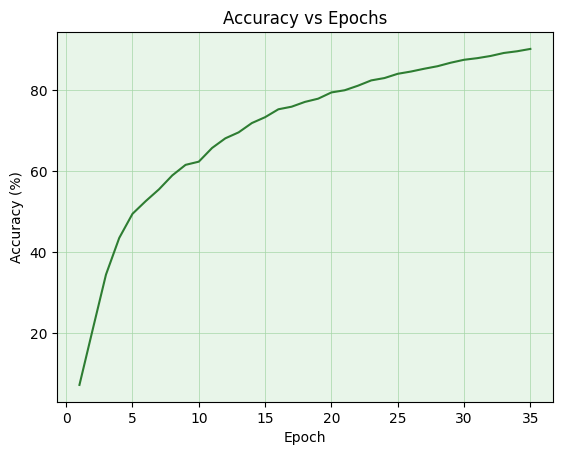

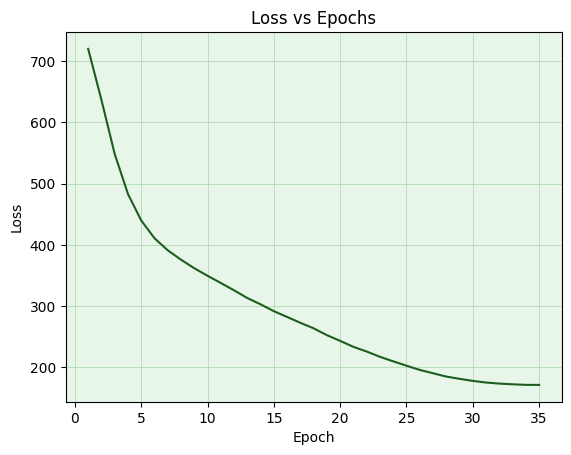

In [9]:
import matplotlib.pyplot as plt

# Data
epochs = list(range(1, 36))
accuracy = [
7.29,20.97,34.52,43.57,49.53,52.67,55.58,59.01,61.61,62.40,
65.78,68.16,69.63,71.93,73.38,75.33,75.97,77.15,77.95,79.49,
80.03,81.15,82.46,83.04,84.09,84.65,85.34,85.96,86.83,87.55,
87.95,88.49,89.23,89.65,90.23
]

loss = [
720.00,636.57,548.30,483.04,439.81,410.85,391.15,375.81,361.87,349.55,
337.79,325.78,313.24,302.91,291.79,282.28,272.80,263.76,252.61,243.26,
233.54,225.87,217.24,209.84,202.77,195.86,190.46,184.96,181.32,177.95,
175.27,173.53,172.38,171.47,171.36
]

# Accuracy Plot
plt.figure()
plt.plot(epochs, accuracy, color="#2e7d32")  # dark green
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True, color="#a5d6a7", linestyle='-', linewidth=0.5)  # light green grid
plt.gca().set_facecolor("#e8f5e9")  # graph paper background
plt.show()

# Loss Plot
plt.figure()
plt.plot(epochs, loss, color="#1b5e20")  # darker green
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, color="#a5d6a7", linestyle='-', linewidth=0.5)
plt.gca().set_facecolor("#e8f5e9")
plt.show()